# ETF rotation: from a predicted ranking to a traded strategy

Everything up to [`13_model_analysis`](13_model_analysis.ipynb) measured how well a model
**orders** the cross-section. Nothing measured what happens when that order is turned into
positions. Those are different questions, and this notebook is where the second one gets asked.

A rank correlation says the top-ranked funds tend to outrun the bottom-ranked ones. A strategy
has to pick a number of them, hold them until the next rebalance, and pay to get in and out. Two
models with the same information coefficient can produce very different Sharpe ratios, because
the IC is an average over the whole cross-section while a top-k rule only ever holds its head.
Where the predicted scores sit relative to each other therefore matters as much as how well they
correlate with what happened.

**This notebook backtests the whole registered population**, not a chosen model. Every validation
prediction set crossed with every declared entry scheme, each one registered under its own hash.
**It selects nothing.** Selection is best validation backtest Sharpe, and it happens once the
sweep exists to select from.

**Learning objectives**

- Say why a backtest engine has to be checked against a signal that carries no information before
  its results on a real one mean anything.
- Run a sweep as orchestration over one backtest call rather than as a second code path.
- Read the relationship between prediction IC and backtest Sharpe, and say what a weak one
  implies for selecting on IC.
- Read a deflated Sharpe ratio as the price of having searched.

**Book reference**: Chapter 16, Sections 16.4 to 16.8.

**Prerequisites**: the modelling notebooks [`06_linear`](06_linear.ipynb) through
[`12_causal_dml`](12_causal_dml.ipynb), whose prediction sets are what this sweeps, and
[`13_model_analysis`](13_model_analysis.ipynb) for what the predictions look like before they are
traded.

**What it writes**: one row in `backtest_runs` per prediction set and entry scheme, at
`stage='signal'`, plus the per-fold and cohort metrics derived from them.
[`15_portfolio_management`](15_portfolio_management.ipynb) takes the leading configurations from
here into the allocation stage.

In [1]:
"""Backtest the registered ETF prediction population across every declared entry scheme."""

import time
import warnings

import plotly.graph_objects as go
import polars as pl

from case_studies.research import open_study, reuse_disclosure, split_unpublished_members
from case_studies.utils.backtest_explorer import BacktestExplorer
from case_studies.utils.backtest_loaders import (
    get_backtest_config,
    load_backtest_prices_for,
    print_stage_dsr_summary,
)
from case_studies.utils.backtest_presets import build_backtest_spec, serializable_backtest_spec
from case_studies.utils.backtest_runner import (
    normalize_prediction_columns,
    run_backtest,
    run_plumbing_test,
)
from case_studies.utils.registry import (
    backtest_hash_from_parts,
    load_existing_backtest_hashes,
    load_prediction_index,
    read_predictions,
)
from case_studies.utils.sweep_config import (
    get_entry_schemes_for,
    get_top_k_values_for,
    get_top_n_predictions,
)
from utils.style import COLORS, show_plotly_with_alt

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "etfs"
LABEL = ""
SPLIT = "validation"
# Zero means the smallest feasible k from setup.yaml backtest.sweep.top_k_grid.
TOP_K = 0
MAX_SYMBOLS = 0
FORCE_REBACKTEST = False
# None means every live prediction set; an int caps the shortlist.
TOP_N_PREDICTIONS = None
# Both names stay bound here although nothing below reads them: that is what makes the harness
# force preview and supply a workspace - `_declares_tier_and_workspace` in `tests/pm_helpers.py`
# looks for exactly this pair. Without them the canonical
# branch regenerates in place, which needs symlinks a CI checkout does not have.
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""

## 1. The protocol, and a test of the engine

The study is opened first, before anything reads the registry. Opening it under the preview
tier activates a workspace and rewrites `ML4T_OUTPUT_DIR` process-wide, which is what every
later `get_case_study_dir` call resolves against. A catalog, an explorer or a candidate index
built before that line points at the released registry while the sweep writes to the preview
one, and the two never meet: the sweep finds nothing registered, and every reader scoped to
hashes from the other root returns empty. Opening first makes one root serve the whole
notebook.

The term sheet below is the whole execution model in one place: which calendar the strategy
trades on, how often it rebalances, what a leg costs, and whether it may go short. None of it is
chosen here - it is declared in `config/setup.yaml` and read back, so a reader can see what the
Sharpe ratios later in this notebook were earned under.

In [3]:
study = open_study(CASE_STUDY_ID, execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None)

bt_config = get_backtest_config(CASE_STUDY_ID)
if TOP_N_PREDICTIONS is None:
    TOP_N_PREDICTIONS = get_top_n_predictions(CASE_STUDY_ID, "signal")
if not LABEL:
    LABEL = bt_config.primary_label

print(f"""=== Protocol term sheet ===
  Case study:    {CASE_STUDY_ID}
  Label:         {LABEL}
  Calendar:      {bt_config.calendar}
  Cadence:       {bt_config.cadence_for(LABEL)}
  Initial cash:  {bt_config.initial_cash:,.0f}
  Share type:    {bt_config.share_type}
  Commission:    {bt_config.commission_bps:.1f} bps
  Slippage:      {bt_config.slippage_bps:.1f} bps
  Total cost:    {bt_config.commission_bps + bt_config.slippage_bps:.1f} bps/leg
  Long/short:    {bt_config.long_short}
""")

=== Protocol term sheet ===
  Case study:    etfs
  Label:         fwd_ret_21d
  Calendar:      NYSE
  Cadence:       monthly_month_end
  Initial cash:  100,000
  Share type:    integer
  Commission:    5.0 bps
  Slippage:      2.0 bps
  Total cost:    7.0 bps/leg
  Long/short:    False



### A signal that knows nothing

Before any real prediction is traded, the engine is run on a **random** signal. A random ranking
carries no information about future returns, so a correctly wired backtest should return a Sharpe
ratio indistinguishable from zero. A materially non-zero one would mean the engine is producing
profit from something other than the signal - a price series read one bar early, a return joined
to the wrong date, a cost model that never fires - and every result below it would inherit that.

The bar is deliberately loose. At this label's decision cadence over a validation window this long there
are few enough rebalances that the sampling noise on a random strategy's Sharpe is itself large,
so a tight threshold would fail on chance alone. What it is built to catch is a pipeline bug,
which produces a Sharpe far outside that noise rather than just outside zero.

In [4]:
prices = load_backtest_prices_for(CASE_STUDY_ID, LABEL, split="validation", max_symbols=MAX_SYMBOLS)
n_assets = prices["symbol"].n_unique()
if TOP_K == 0:
    _feasible_top_k = get_top_k_values_for(CASE_STUDY_ID, LABEL, n_assets)
    if not _feasible_top_k:
        raise ValueError(
            f"top_k_grid for {LABEL!r} in {CASE_STUDY_ID} has no value < "
            f"n_assets={n_assets}; declare a feasible k in setup.yaml"
        )
    TOP_K = _feasible_top_k[0]
print(f"Prices: {len(prices):,} rows, {n_assets} tradeable funds; plumbing-test TOP_K={TOP_K}")

Prices: 198,877 rows, 100 tradeable funds; plumbing-test TOP_K=5


In [5]:
PLUMBING_SHARPE_LIMIT = 1.5

strategy_spec = build_backtest_spec(
    CASE_STUDY_ID,
    bt_config,
    prices=prices,
    prediction_hash="plumbing_test",
    initial_cash=bt_config.initial_cash,
    chapter="ch16",
    signal={
        "method": "score_weighted_top_k",
        "top_k": TOP_K,
        "long_short": bt_config.long_short,
    },
    label=LABEL,
)

try:
    random_sharpe = run_plumbing_test(
        CASE_STUDY_ID,
        prices,
        strategy_spec,
        top_k=TOP_K,
        initial_cash=bt_config.initial_cash,
        calendar=bt_config.calendar,
    )
except ValueError as error:
    if "zero variance" not in str(error).lower():
        raise
    # A reduced run can leave too few funds for a top-k rotation to move at all, which is a
    # property of the reduction rather than of the engine. Saying so is not the same as passing.
    print(f"Plumbing test could not run: {error}")
    random_sharpe = None

if random_sharpe is not None:
    print(f"Random-signal Sharpe: {random_sharpe:+.3f} (limit {PLUMBING_SHARPE_LIMIT})")
    if abs(random_sharpe) >= PLUMBING_SHARPE_LIMIT:
        raise RuntimeError(
            f"a random signal earned Sharpe {random_sharpe:+.3f}, outside the "
            f"{PLUMBING_SHARPE_LIMIT} limit; the engine is producing return from something "
            "other than the signal and every backtest below would inherit it"
        )

Random-signal Sharpe: +0.308 (limit 1.5)


## 2. The sweep

Every registered validation prediction set is crossed with every declared entry scheme. The
schemes differ only in how many funds the rule holds, which is the one portfolio-construction
choice this stage varies: everything else - the calendar, the costs, the rebalance rule - is the
same for all of them, so a Sharpe difference between two rows is attributable to the prediction
or to the concentration, and not to the execution model.

**The sweep is orchestration, not a second code path.** Each combination calls the same
`run_backtest`, so a result registered here is the same computation a reader gets calling it
directly. Each is hashed from the prediction identity and the serialized specification, so a
combination already in the registry is skipped rather than recomputed, and an interrupted sweep
resumes where it stopped.

**What the index is, and what it is not.** `load_prediction_index` returns every registered
prediction set for this label and split. That is the catalog, and the catalog carries no
lineage: when a model notebook refits, it publishes a second generation under the same
population name and the first generation's rows stay behind - complete, current under a schema
version that has not moved, and indistinguishable in this table from the rows that replaced
them. Sweeping both does not fail. It backtests twice, ranks a retired identity against a live
one, and carries whichever wins into every stage downstream.

`split_unpublished_members` asks the population lineage instead of the catalog, and the
excluded side is printed rather than counted, so a reader can see which configurations left the
sweep and why.

It asks membership, not retirement, and the difference is the rows no population ever listed.
Nobody retired an experimental fit, so an exclusion set admits it and it can outrank a
published identity and be carried into every stage downstream. Measured on this registry:
682 validation prediction sets, 134 superseded, 498 published - and 50 that are live by
exclusion and listed by no population at all. Where a registry declares no populations, which
is a fixture or a study written before the mechanism, membership cannot be asked and the
exclusion split stands in rather than narrowing every candidate to nothing.

In [6]:
pred_index = load_prediction_index(CASE_STUDY_ID, label=LABEL, split=SPLIT)
if pred_index.is_empty():
    raise RuntimeError(f"no predictions registered for {CASE_STUDY_ID}/{LABEL}/{SPLIT}")

candidates = split_unpublished_members(study, pred_index)
pred_index = candidates.live
if pred_index.is_empty():
    raise RuntimeError(
        f"no registered prediction set for {CASE_STUDY_ID}/{LABEL}/{SPLIT} is listed by a "
        "current population, so there is nothing published to sweep"
    )
print(f"Registered prediction sets: {candidates.live.height + candidates.retired.height:,}")
if candidates.retired.is_empty():
    print("Not published by any current population: none")
else:
    print(f"Not published by any current population: {candidates.retired.height:,}")
    print(
        candidates.retired.group_by("family", "config_name")
        .agg(n=pl.len(), ic_max=pl.col("ic_mean").max())
        .sort("n", descending=True)
    )

if TOP_N_PREDICTIONS > 0:
    pred_index = pred_index.head(TOP_N_PREDICTIONS)

# The population every reader below is scoped to. The retired backtests a previous sweep
# registered are still in the registry, so a reader that names no population reports over them
# even when this run's sweep skipped those rows.
LIVE_PREDICTIONS = pred_index["prediction_hash"].to_list()

entry_schemes = get_entry_schemes_for(
    CASE_STUDY_ID, LABEL, n_assets, long_short=bt_config.long_short
)
n_predictions, n_schemes = len(pred_index), len(entry_schemes)
total_backtests = n_predictions * n_schemes

ic_min, ic_max = pred_index["ic_mean"].min(), pred_index["ic_mean"].max()
print(f"Prediction sets to sweep: {n_predictions}")
print(
    f"  IC range: {ic_min:+.4f} to {ic_max:+.4f}"
    if ic_min is not None
    else "  IC range: not yet computed"
)
print(f"Entry schemes ({n_schemes}):")
for scheme in entry_schemes:
    print(f"  {scheme['name']}: {scheme['method']} (top_k={scheme.get('top_k', '-')})")
print(f"Grid: {n_predictions} x {n_schemes} = {total_backtests} backtests")

# A grid with no entry scheme is not an empty sweep, it is a sweep that cannot happen, and the
# loop below completes over it in no time and reports "0 computed, 0 served, 0 failed" - a line
# indistinguishable from a re-run where everything was already registered. Every downstream
# notebook then fails on the absence instead, several stages away from the cause.
#
# `get_entry_schemes_for` drops any declared concentration at or above the traded universe,
# because holding k of k funds is the equal-weight benchmark rather than a ranking. So a
# universe reduced below the smallest declared k removes every scheme at once, which is what a
# reduced run does when its symbol cap is set without reference to `backtest.sweep.top_k_grid`.
#
# The feasibility check above it fires only when `TOP_K` is left at 0, so a run that names a
# concentration for the plumbing test skips it and reaches here with nothing to sweep. This one
# is about the sweep and runs either way.
if not entry_schemes:
    raise RuntimeError(
        f"no entry scheme is feasible for {CASE_STUDY_ID}/{LABEL}: every concentration declared "
        f"in backtest.sweep.top_k_grid is at or above the {n_assets} funds this run trades, so "
        "each of them would hold the whole universe rather than a ranked selection. Raise the "
        "symbol cap above the smallest declared concentration, or declare a smaller one."
    )

Registered prediction sets: 323
Not published by any current population: 60
shape: (3, 4)
┌───────────────┬─────────────┬─────┬───────────┐
│ family        ┆ config_name ┆ n   ┆ ic_max    │
│ ---           ┆ ---         ┆ --- ┆ ---       │
│ str           ┆ str         ┆ u32 ┆ f64       │
╞═══════════════╪═════════════╪═════╪═══════════╡
│ deep_learning ┆ lstm_h64    ┆ 20  ┆ -0.010201 │
│ deep_learning ┆ tsmixer     ┆ 20  ┆ 0.035844  │
│ deep_learning ┆ nlinear     ┆ 20  ┆ 0.031963  │
└───────────────┴─────────────┴─────┴───────────┘
Prediction sets to sweep: 263
  IC range: -0.0326 to +0.0882
Entry schemes (3):
  ew_top5: equal_weight_top_k (top_k=5)
  ew_top10: equal_weight_top_k (top_k=10)
  ew_top20: equal_weight_top_k (top_k=20)
Grid: 263 x 3 = 789 backtests


A backtest that raises is recorded with the reason it raised rather than as a bare count. A sweep
that failed on every row would otherwise report a number and no cause, which is indistinguishable
from a sweep that failed on one.

The summary counts what was **computed** separately from what was **served from the registry**. A
re-run finds every combination already registered and returns each from cache in no time at all;
reporting that as a completed sweep is a wrong number that looks exactly like a right one, and it
gets more wrong every time the notebook is re-run. The registered hashes are snapshotted before
the loop, and each result is classified against that snapshot rather than against whether the
call happened to be fast.

In [7]:
results = []
failures = []
skipped = 0
served = 0
registered_before = load_existing_backtest_hashes(CASE_STUDY_ID, stage="signal")
existing_hashes = set(registered_before)
print(f"Signal-stage backtests already registered: {len(registered_before):,}")

started = time.time()
completed = 0
for i, pred_row in enumerate(pred_index.iter_rows(named=True)):
    pred_hash = pred_row["prediction_hash"]

    pending = []
    for j, scheme in enumerate(entry_schemes):
        signal = {
            "method": scheme["method"],
            "top_k": scheme.get("top_k", 20),
            "long_short": bt_config.long_short,
        }
        signal.update({k: v for k, v in scheme.items() if k not in ("name", "method")})
        spec = build_backtest_spec(
            CASE_STUDY_ID,
            bt_config,
            prices=prices,
            prediction_hash=pred_hash,
            initial_cash=bt_config.initial_cash,
            chapter="ch16",
            signal=signal,
            label=LABEL,
        )
        already = backtest_hash_from_parts(pred_hash, serializable_backtest_spec(spec))
        if already in existing_hashes and not FORCE_REBACKTEST:
            skipped += 1
            continue
        # The grid position travels with the work rather than being read off the loop variable
        # afterwards: the inner loop runs to the end building this list, so its last value would
        # be reported for every scheme in the batch.
        pending.append((i * n_schemes + j + 1, scheme, spec))

    if not pending:
        continue

    predictions = normalize_prediction_columns(read_predictions(CASE_STUDY_ID, pred_hash))
    for position, scheme, spec in pending:
        try:
            result = run_backtest(
                CASE_STUDY_ID,
                pred_hash,
                spec,
                prices=prices,
                predictions=predictions,
                label=LABEL,
                register=True,
                force_rebacktest=FORCE_REBACKTEST,
                initial_cash=bt_config.initial_cash,
                calendar=bt_config.calendar,
            )
        except Exception as error:
            failures.append(
                {
                    "prediction_hash": pred_hash,
                    "family": pred_row["family"],
                    "config_name": pred_row["config_name"],
                    "signal_method": scheme["name"],
                    "error": f"{type(error).__name__}: {error}",
                }
            )
            continue

        results.append(
            {
                "prediction_hash": pred_hash,
                "source": pred_row["source"],
                "ic_mean": pred_row["ic_mean"],
                "family": pred_row["family"],
                "config_name": pred_row["config_name"],
                "signal_method": scheme["name"],
                "backtest_hash": result.backtest_hash,
                "sharpe": result.metrics["sharpe"],
                "total_return": result.metrics["total_return"],
                "max_drawdown": result.metrics["max_drawdown"],
                "cagr": result.metrics.get("cagr", 0.0),
                "volatility": result.metrics.get("volatility", 0.0),
                "num_trades": result.metrics.get("num_trades", 0),
            }
        )
        if result.backtest_hash in registered_before:
            served += 1
        if result.backtest_hash:
            existing_hashes.add(result.backtest_hash)
        completed += 1
        if completed % 50 == 0:
            elapsed = time.time() - started
            print(
                f"  [{position}/{total_backtests}] {elapsed:.0f}s "
                f"({completed / elapsed:.1f} bt/s) | failed: {len(failures)}"
            )

elapsed = time.time() - started
print(
    f"\nSweep complete in {elapsed:.0f}s: "
    f"{reuse_disclosure(len(results) - served, served + skipped, len(failures))}"
)

Signal-stage backtests already registered: 1,638


  [440/789] 276s (0.2 bt/s) | failed: 0


  [628/789] 535s (0.2 bt/s) | failed: 0



Sweep complete in 646s: computed 120, reused 669 from the registry


In [8]:
if failures:
    failure_frame = pl.DataFrame(failures)
    print(f"{failure_frame.height} backtests raised. Distinct causes:")
    print(failure_frame.group_by("error").len().sort("len", descending=True))
    print(failure_frame.head(10))
else:
    print("every backtest in the grid either ran or was already registered")

every backtest in the grid either ran or was already registered


## 3. Reading the sweep

From here the notebook is **read-only**: it queries the registry through `BacktestExplorer`
rather than the list the sweep just built. Nothing below depends on the sweep having run in this
session, so a reader who arrives at a populated registry sees the same tables as one who just
filled it, and a run that resumed after an interruption reports the whole population rather than
the part it happened to compute.

In [9]:
explorer = BacktestExplorer(CASE_STUDY_ID)
print(repr(explorer))

BacktestExplorer('etfs', 2193 runs: allocation=360, cost_sensitivity=34, holdout=1, risk_overlay=40, signal=1758)


### The leading configurations

Sorted by Sharpe over the validation window, net of the costs the term sheet declares. The
`source` column names the model family and configuration whose predictions the row traded, and
`signal_method` the entry scheme, so a family appearing several times with different schemes is
telling you how much the concentration choice moved it.

The second table groups the whole stage by model family. What it answers is whether the ordering
by prediction quality carries through to the ordering by traded performance - and the column to
look at is not only the mean but the spread, because a family whose configurations disagree
widely is one whose leading Sharpe owes more to which configuration was picked than to the family
it came from.

In [10]:
top = explorer.best(stage="signal", top_n=10, prediction_hashes=LIVE_PREDICTIONS)
print("Leading signal-stage backtests:")
print(top.select("source", "signal_method", "sharpe", "cagr", "max_drawdown"))
print("\nBy model family:")
print(explorer.compare_families(stage="signal", prediction_hashes=LIVE_PREDICTIONS))

Leading signal-stage backtests:
shape: (10, 5)
┌─────────────────────┬────────────────────┬──────────┬──────────┬──────────────┐
│ source              ┆ signal_method      ┆ sharpe   ┆ cagr     ┆ max_drawdown │
│ ---                 ┆ ---                ┆ ---      ┆ ---      ┆ ---          │
│ str                 ┆ str                ┆ f64      ┆ f64      ┆ f64          │
╞═════════════════════╪════════════════════╪══════════╪══════════╪══════════════╡
│ gbm/leaves_63_huber ┆ equal_weight_top_k ┆ 0.739773 ┆ 0.145953 ┆ -0.41941     │
│ latent_factors/cae  ┆ equal_weight_top_k ┆ 0.734171 ┆ 0.14697  ┆ -0.342932    │
│ latent_factors/cae  ┆ equal_weight_top_k ┆ 0.724966 ┆ 0.162357 ┆ -0.345551    │
│ gbm/leaves_63_huber ┆ equal_weight_top_k ┆ 0.724812 ┆ 0.142583 ┆ -0.43655     │
│ latent_factors/cae  ┆ equal_weight_top_k ┆ 0.723992 ┆ 0.130486 ┆ -0.295909    │
│ gbm/default_huber   ┆ equal_weight_top_k ┆ 0.709296 ┆ 0.13634  ┆ -0.439336    │
│ gbm/leaves_63_huber ┆ equal_weight_top_k ┆ 0.7082

shape: (5, 6)
┌────────────────┬─────┬───────────────┬────────────┬────────────┬──────────────┐
│ family         ┆ n   ┆ sharpe_median ┆ sharpe_max ┆ sharpe_q75 ┆ pct_positive │
│ ---            ┆ --- ┆ ---           ┆ ---        ┆ ---        ┆ ---          │
│ str            ┆ u32 ┆ f64           ┆ f64        ┆ f64        ┆ f64          │
╞════════════════╪═════╪═══════════════╪════════════╪════════════╪══════════════╡
│ latent_factors ┆ 81  ┆ 0.52442       ┆ 0.734171   ┆ 0.570245   ┆ 100.0        │
│ gbm            ┆ 447 ┆ 0.4924        ┆ 0.739773   ┆ 0.543681   ┆ 100.0        │
│ deep_learning  ┆ 120 ┆ 0.444255      ┆ 0.654045   ┆ 0.494754   ┆ 100.0        │
│ tabular_dl     ┆ 72  ┆ 0.438247      ┆ 0.622861   ┆ 0.511242   ┆ 100.0        │
│ linear         ┆ 66  ┆ 0.416851      ┆ 0.532268   ┆ 0.454826   ┆ 100.0        │
└────────────────┴─────┴───────────────┴────────────┴────────────┴──────────────┘


### Does a better ranking make a better strategy?

The left panel is the distribution of every Sharpe in the sweep, with a line at zero. The right
panel puts each backtest's Sharpe against the information coefficient of the prediction set it
traded. A tight upward relationship would mean IC is a sufficient selection criterion; a diffuse
one means it is not, and that two configurations with the same IC can trade very differently.

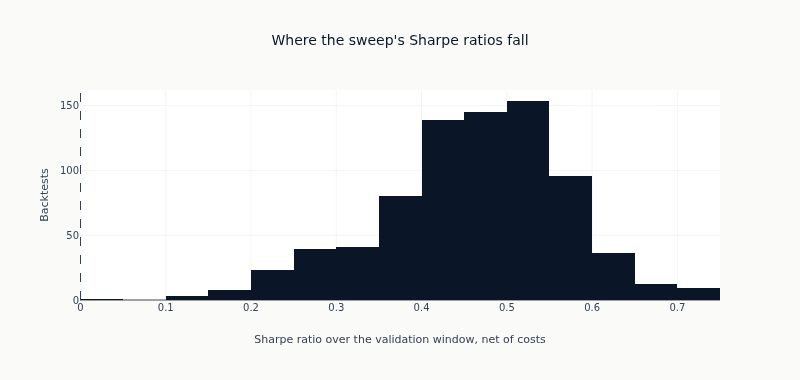

In [11]:
all_signal = explorer.best(stage="signal", top_n=100000, prediction_hashes=LIVE_PREDICTIONS)
if all_signal.is_empty():
    raise RuntimeError("no signal-stage backtests are registered, so there is nothing to read")

sharpes = all_signal["sharpe"].drop_nulls()
paired = all_signal.select("ic_mean", "sharpe").drop_nulls()

fig = go.Figure(
    go.Histogram(x=sharpes.to_list(), nbinsx=30, marker_color=COLORS["blue"], showlegend=False)
)
fig.add_vline(x=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"])
fig.update_xaxes(title_text="Sharpe ratio over the validation window, net of costs")
fig.update_yaxes(title_text="Backtests")
fig.update_layout(
    title="Where the sweep's Sharpe ratios fall",
    height=380,
    width=800,
    margin=dict(t=90),
)
show_plotly_with_alt(
    fig,
    "Histogram of the net Sharpe ratio of every signal-stage backtest in the sweep, with a dashed "
    f"line at zero. Counted from the frame: {sharpes.len()} backtests, Sharpe from "
    f"{sharpes.min():+.2f} to {sharpes.max():+.2f}, median {sharpes.median():+.2f}, "
    f"{(sharpes > 0).sum()} above zero.",
)

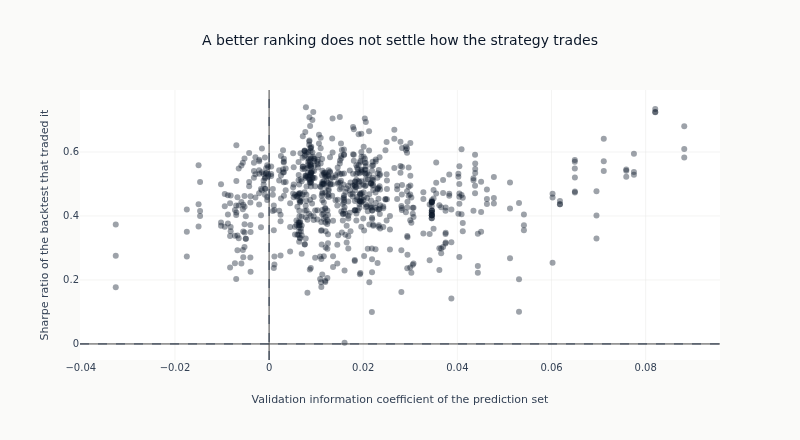

In [12]:
rank_corr = (
    paired.select(pl.corr("ic_mean", "sharpe", method="spearman")).item()
    if paired.height > 2
    else None
)
fig = go.Figure(
    go.Scatter(
        x=paired["ic_mean"].to_list(),
        y=paired["sharpe"].to_list(),
        mode="markers",
        marker=dict(color=COLORS["blue"], size=6, opacity=0.4),
        showlegend=False,
    )
)
fig.add_hline(y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"])
fig.add_vline(x=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"])
fig.update_xaxes(title_text="Validation information coefficient of the prediction set")
fig.update_yaxes(title_text="Sharpe ratio of the backtest that traded it")
fig.update_layout(
    title="A better ranking does not settle how the strategy trades",
    height=440,
    width=800,
    margin=dict(t=90),
)
show_plotly_with_alt(
    fig,
    "Scatter of each signal-stage backtest's net Sharpe ratio against the information coefficient "
    "of the prediction set it traded, with dashed lines at zero on both axes. Counted from the "
    f"frame: {paired.height} backtests, IC from {paired['ic_mean'].min():+.3f} to "
    f"{paired['ic_mean'].max():+.3f}, Sharpe from {paired['sharpe'].min():+.2f} to "
    f"{paired['sharpe'].max():+.2f}, rank correlation between the two "
    + ("not computed" if rank_corr is None else f"{rank_corr:+.2f}")
    + ".",
)

In [13]:
print(f"backtests with both an IC and a Sharpe: {paired.height}")
print(
    "rank correlation between prediction IC and backtest Sharpe: "
    + ("not computed" if rank_corr is None else f"{rank_corr:+.3f}")
)

backtests with both an IC and a Sharpe: 786
rank correlation between prediction IC and backtest Sharpe: -0.007


**A top-k rule only ever holds the head of the ranking.** The information coefficient averages
over the whole cross-section, so it credits a model equally for ordering the middle correctly and
for ordering the top correctly - and only the second reaches the portfolio. Two prediction sets
with the same IC can differ in how far the top few funds are separated from the rest, how often
that top few changes, and therefore in how much of the ranking is left after the rebalance and
the cost of turning it over. That is the mechanism behind whatever spread the scatter above shows,
and it is the reason selection happens on backtest Sharpe rather than on IC.

### The price of having searched

A sweep this size will produce a leading Sharpe ratio even when no configuration has any skill,
for the same reason the highest of many draws exceeds their mean. The deflated Sharpe ratio asks
the question that follows: given that this many variants were tried, and given how non-normal
these returns are, what is the probability the leader's Sharpe is genuinely above the benchmark?

$$DSR = \Phi\left[\frac{(\hat{SR} - SR^*) \sqrt{T-1}}
{\sqrt{1 - \hat{\gamma}_3 \hat{SR} + \frac{\hat{\gamma}_4 - 1}{4} \hat{SR}^2}}\right]$$

$SR^*$ is the Sharpe the leader of $K$ independent zero-skill variants would be expected to
reach,
so it rises with the size of the sweep. A low-frequency cadence gives fewer return observations than a
daily strategy does, which makes $T$ small and the correction correspondingly large: this
universe pays more for its search than a higher-frequency one would.

In [14]:
print_stage_dsr_summary(explorer, top_n=20, head=10, prediction_hashes=LIVE_PREDICTIONS)


--- DSR @ equal-weight baseline (K=20) ---
shape: (10, 22)
┌────────────┬────────────┬────────────┬────────┬───┬────────────┬────────────┬───────────┬────────┐
│ source     ┆ family     ┆ label      ┆ sharpe ┆ … ┆ ras_leader ┆ ras_pvalue ┆ reality_c ┆ pbo    │
│ ---        ┆ ---        ┆ ---        ┆ ---    ┆   ┆ ---        ┆ ---        ┆ heck_pval ┆ ---    │
│ str        ┆ str        ┆ str        ┆ f64    ┆   ┆ f64        ┆ null       ┆ ue        ┆ f64    │
│            ┆            ┆            ┆        ┆   ┆            ┆            ┆ ---       ┆        │
│            ┆            ┆            ┆        ┆   ┆            ┆            ┆ null      ┆        │
╞════════════╪════════════╪════════════╪════════╪═══╪════════════╪════════════╪═══════════╪════════╡
│ gbm/leaves ┆ gbm        ┆ fwd_ret_21 ┆ 0.7398 ┆ … ┆ 0.4576     ┆ null       ┆ null      ┆ 0.3143 │
│ _63_huber  ┆            ┆ d          ┆        ┆   ┆            ┆            ┆           ┆        │
│ latent_fac ┆ latent_fac ┆ fwd


--- DSR @ allocation (K=20) ---
shape: (10, 22)
┌────────────┬────────────┬────────────┬────────┬───┬────────────┬────────────┬───────────┬────────┐
│ source     ┆ family     ┆ label      ┆ sharpe ┆ … ┆ ras_leader ┆ ras_pvalue ┆ reality_c ┆ pbo    │
│ ---        ┆ ---        ┆ ---        ┆ ---    ┆   ┆ ---        ┆ ---        ┆ heck_pval ┆ ---    │
│ str        ┆ str        ┆ str        ┆ f64    ┆   ┆ f64        ┆ null       ┆ ue        ┆ f64    │
│            ┆            ┆            ┆        ┆   ┆            ┆            ┆ ---       ┆        │
│            ┆            ┆            ┆        ┆   ┆            ┆            ┆ f64       ┆        │
╞════════════╪════════════╪════════════╪════════╪═══╪════════════╪════════════╪═══════════╪════════╡
│ latent_fac ┆ latent_fac ┆ fwd_ret_21 ┆ 0.833  ┆ … ┆ 0.5645     ┆ null       ┆ 0.8195    ┆ 0.6714 │
│ tors/cae   ┆ tors       ┆ d          ┆        ┆   ┆            ┆            ┆           ┆        │
│ gbm/leaves ┆ gbm        ┆ fwd_ret_21 ┆ 0

### Where the leading prediction goes next

The stages after this one add portfolio construction, then costs, then a risk overlay, and each
registers its own backtest of the same prediction. Tracking one prediction across them is how the
rest of the case study answers where value is added and where it is spent. Only the signal stage
exists at this point; the rows below fill in as [`15_portfolio_management`](
15_portfolio_management.ipynb), [`17_costs`](17_costs.ipynb) and
[`16_risk_management`](16_risk_management.ipynb) run.

In [15]:
best_prediction = top["prediction_hash"][0]
progression = explorer.progression(best_prediction)
print(f"Sharpe progression for {top['source'][0]}:")
progression.select("stage", "sharpe", "cagr", "max_drawdown") if not progression.is_empty() else (
    print("no stages registered for this prediction yet")
)

Sharpe progression for gbm/leaves_63_huber:


stage,sharpe,cagr,max_drawdown
str,f64,f64,f64
"""signal""",0.739773,0.145953,-0.41941
"""allocation""",0.795395,0.148885,-0.422997


## 4. What to notice

**The engine was checked before it was trusted.** A random signal earning a Sharpe near zero is
not a result about the ETF universe; it is the precondition for every result that follows being
about the ETF universe rather than about a join. That check runs on every execution of this
notebook rather than once, because the thing it protects against is a change made later.

**Nothing here is selected.** Every registered prediction set was backtested, including ones
whose validation IC gives no reason to expect anything, and they are all in the registry with
their hashes. That is what makes the selection in the stages that follow a decision made on a
stated rule over a known population, rather than a choice among whatever was run.

**The deflated Sharpe is not a filter applied to the leader; it is a statement about the sweep.**
It changes when the number of variants changes, so it answers "was this leader worth finding
among this many" and not "is this strategy sound". A reader who runs a smaller grid gets a
different deflation on the same strategy, and both numbers are correct.

**Known limitations.** The costs are a declared commission and slippage per leg rather than a
measured impact model, so a scheme holding fewer funds is charged the same rate per trade as one
holding more even though its positions are larger. The prices are the ones this case study
materialized, with no borrow cost and no capacity limit. And every Sharpe here is measured on
validation folds that have been read many times over by the time a case study reaches this
notebook; the holdout is not consulted anywhere in this notebook.

**Next**: [`15_portfolio_management`](15_portfolio_management.ipynb) takes the leading
configurations into the allocation stage and asks how much of this Sharpe is the prediction and
how much is the equal weighting it was traded under.